In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION'

In [3]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True  # Optimize backend performance
torch.cuda.reset_peak_memory_stats()

In [4]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
root_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET'
train_images_dir = os.path.join(root_dir, 'train/images')
train_masks_dir = os.path.join(root_dir, 'train/masks')
val_images_dir = os.path.join(root_dir, 'val/images')
val_masks_dir = os.path.join(root_dir, 'val/masks')

# Custom Dataset
class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.transform = transform
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_filenames[idx])
        
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = mask.astype(np.float32) / 255.0
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask).unsqueeze(0)  # Ensure mask shape [1, H, W]
        
        return image, mask.squeeze(0)  # Ensure mask shape [H, W]

# Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = RooftopDataset(train_images_dir, train_masks_dir, transform)
val_dataset = RooftopDataset(val_images_dir, val_masks_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

# U-Net Model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder = nn.ModuleList([
            conv_block(3, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        ])
        
        self.pool = nn.MaxPool2d(2)
        
        self.upconv = nn.ModuleList([
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        ])
        
        self.decoder = nn.ModuleList([
            conv_block(256, 128),
            conv_block(128, 64),
            conv_block(64, 32),
            conv_block(32, 16)
        ])
        
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        enc_outs = []
        for enc in self.encoder:
            x = enc(x)
            enc_outs.append(x)
            x = self.pool(x)
        
        for i in range(4):
            x = self.upconv[i](x)
            enc_out = enc_outs[-(i+2)]
            if x.shape[2:] != enc_out.shape[2:]:
                x = nn.functional.interpolate(x, size=enc_out.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, enc_out], dim=1)
            x = self.decoder[i](x)
        
        return torch.sigmoid(self.final_conv(x))

# Training Setup
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
def train(model, train_loader, val_loader, epochs=50):
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)  # Ensure correct shape [B, 1, H, W]
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    
    torch.save(model.state_dict(), "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/unet_tree_50_2.pth")
    torch.save(model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/full_unet_tree_50_2.pth")
    
    print("Model saved!")

train(model, train_loader, val_loader,epochs=50)

Using device: cuda
Epoch 1/50, Loss: 0.7498
Epoch 2/50, Loss: 0.5158
Epoch 3/50, Loss: 0.4093
Epoch 4/50, Loss: 0.3963
Epoch 5/50, Loss: 0.3799
Epoch 6/50, Loss: 0.3729
Epoch 7/50, Loss: 0.3636
Epoch 8/50, Loss: 0.3568
Epoch 9/50, Loss: 0.3541
Epoch 10/50, Loss: 0.3523
Epoch 11/50, Loss: 0.3497
Epoch 12/50, Loss: 0.3482
Epoch 13/50, Loss: 0.3459
Epoch 14/50, Loss: 0.3412
Epoch 15/50, Loss: 0.3422
Epoch 16/50, Loss: 0.3396
Epoch 17/50, Loss: 0.3367
Epoch 18/50, Loss: 0.3356
Epoch 19/50, Loss: 0.3308
Epoch 20/50, Loss: 0.3293
Epoch 21/50, Loss: 0.3282
Epoch 22/50, Loss: 0.3252
Epoch 23/50, Loss: 0.3212
Epoch 24/50, Loss: 0.3210
Epoch 25/50, Loss: 0.3219
Epoch 26/50, Loss: 0.3265
Epoch 27/50, Loss: 0.3241
Epoch 28/50, Loss: 0.3211
Epoch 29/50, Loss: 0.3231
Epoch 30/50, Loss: 0.3182
Epoch 31/50, Loss: 0.3180
Epoch 32/50, Loss: 0.3201
Epoch 33/50, Loss: 0.3150
Epoch 34/50, Loss: 0.3162
Epoch 35/50, Loss: 0.3158
Epoch 36/50, Loss: 0.3139
Epoch 37/50, Loss: 0.3186
Epoch 38/50, Loss: 0.3151
Ep

In [5]:
# Evaluation

def evaluate(model, val_loader):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            
            intersection = (preds * masks).sum()
            union = (preds + masks).sum() - intersection
            iou = intersection / (union + 1e-6)
            iou_scores.append(iou.item())
    
    print(f"Mean IoU Score: {np.mean(iou_scores):.4f}")
    return iou_scores


iou_score = evaluate(model, val_loader)

Mean IoU Score: 0.2825


In [6]:
losses = [0.7498,0.5158,0.4093,0.3963,0.3799,0.3729,0.3636,0.3568,0.3541,0.3523,0.3497,0.3482,0.3459,0.3412,0.3422,0.3396,0.3367,0.3356,0.3308,0.3293,0.3282,0.3252,0.3212,0.3210,0.3219,0.3265,0.3241,0.3211,0.3231,0.3182,0.3180,0.3201,0.3150,0.3162,0.3158,0.3139,0.3186,0.3151,0.3126,0.3095,0.3079,0.3068,0.3097,0.3026,0.3066,0.3097,0.2956,0.3049,0.3017,0.2917]

In [7]:
len(losses)

50

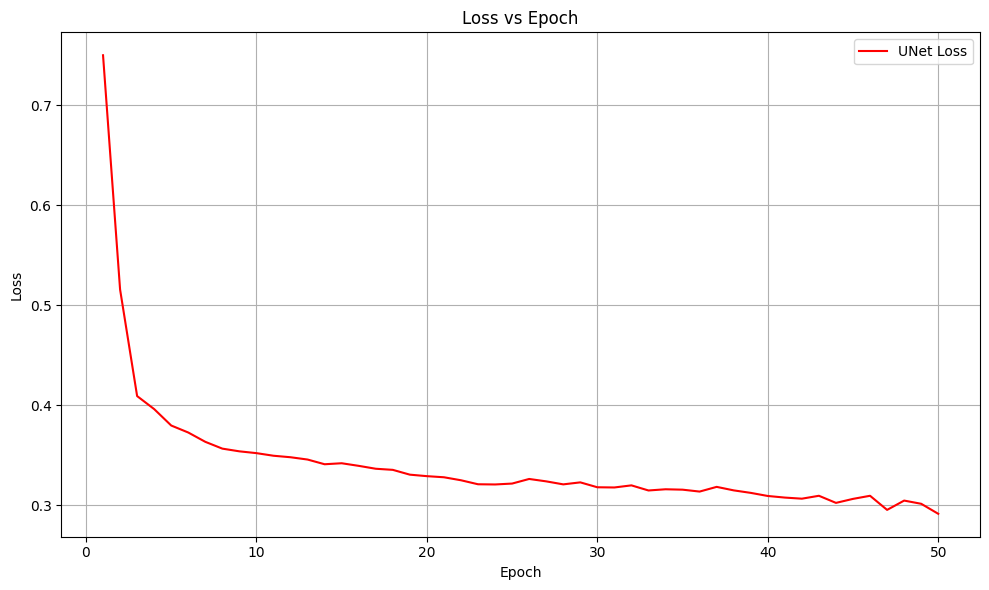

In [8]:
import matplotlib.pyplot as plt

unet_loss = losses
epochs = list(range(1,51))

plt.figure(figsize=(10, 6))
# plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.plot(epochs, unet_loss, label='UNet Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/loss_vs_epoch_UNET_50.png')
plt.tight_layout()
plt.show()